<a href="https://colab.research.google.com/github/Abdallah-Osama-cpp/heart-disease-prediction/blob/main/Copy_of_Heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

: 

In [ ]:
df = pd.read_csv('./assets/train_data.csv') # train data
dt = pd.read_csv('./assets/test_data.csv')  # test data

**DATA EXPLORE**

In [ ]:
df.head(10)

In [ ]:
dt.head(10)

In [ ]:
df.info()

In [ ]:
dt.info()

In [ ]:
df.describe()

In [ ]:
dt.describe()

In [ ]:
df = df.drop(columns=['id'])
dt = dt.drop(columns=['id'])

**HANDLING NULLS**

In [ ]:
train_age_median = df['Age'].median()
train_gender_mode = df['Gender'].mode()[0]
train_work_mode = df['work_type'].mode()[0]
train_smoking_mode = df['smoking_status'].mode()[0]

df['Age'].fillna(train_age_median, inplace=True)
df['Gender'].fillna(train_gender_mode, inplace=True)
df['work_type'].fillna(train_work_mode, inplace=True)
df['smoking_status'].fillna(train_smoking_mode, inplace=True)

dt['Age'].fillna(train_age_median, inplace=True)
dt['work_type'].fillna(train_work_mode, inplace=True)
dt['smoking_status'].fillna(train_smoking_mode, inplace=True)

In [ ]:
df.info()

In [ ]:
dt.info()

**ENCODING**

In [ ]:
df.head()

In [ ]:
df['Gender'].unique()


In [ ]:
dt['Gender'].unique()

In [ ]:
df['smoking_status'].unique()


In [ ]:
dt['smoking_status'].unique()

In [ ]:
df['work_type'].unique()


In [ ]:
dt['work_type'].unique()

In [ ]:
df['Heart Disease'].unique()


In [ ]:
dt['Heart Disease'].unique()

In [ ]:
df['Heart Disease'] = df['Heart Disease'].map({'No': 0, 'Yes': 1})
dt['Heart Disease'] = dt['Heart Disease'].map({'No': 0, 'Yes': 1})

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
dt['Gender'] = dt['Gender'].map({'Male': 1, 'Female': 0})

df = pd.get_dummies(df, columns=['smoking_status', 'work_type'], drop_first=False)
dt = pd.get_dummies(dt, columns=['smoking_status', 'work_type'], drop_first=False)

dt = dt.reindex(columns=df.columns, fill_value=0)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
dt[bool_cols] = dt[bool_cols].astype(int)


In [ ]:
df.info()

In [ ]:
dt.info()

In [ ]:
df.head()

**Separate features (X) and target (y)**

In [ ]:
X_train = df.drop('Heart Disease', axis=1)
y_train = df['Heart Disease']

X_test = dt.drop('Heart Disease', axis=1)
y_test = dt['Heart Disease']

**Visualizing Outliers with Box Plots**

In [ ]:
numerical_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=X_train[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

**Identifying Outlier Indices using IQR**

In [ ]:
outlier_indices = {}
for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    col_outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)].index.tolist()
    outlier_indices[col] = col_outliers

    print(f"Column: {col}")
    print(f"  Number of outliers: {len(col_outliers)}")
    print(f"  Outlier indices: {col_outliers}\n")

**Capping Outliers using IQR**

In [ ]:
for col in numerical_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers in X_train
    X_train[col] = X_train[col].clip(lower=lower_bound, upper=upper_bound)

    # Cap outliers in X_test using bounds from X_train
    X_test[col] = X_test[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers capped successfully in X_train and X_test.")

display(X_train.head())
display(X_test.head())

**Visualizing Outliers after Capping with Box Plots**

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=X_train[col])
    plt.title(f'Box Plot of {col} (After Capping)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

**Scaling Numerical Features**

In [ ]:


scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

display(X_train.head())

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report)

y_pred = model.predict(X_test_scaled)
print("ress")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred):.4f}")

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as s

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
s.heatmap(cm, annot=True, fmt='d', cmap='Blues',
          xticklabels=['No Disease', 'Disease'],
          yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

results = []

C_values = [0.01, 0.1, 1, 10, 100]
iter_values = [100, 500, 1000]

for c in C_values:
    for it in iter_values:
        m = LogisticRegression(C=c, max_iter=it, random_state=42)
        m.fit(X_train_scaled, y_train)
        pred = m.predict(X_test_scaled)
        results.append({
            'C': c,
            'max_iter': it,
            'Accuracy': round(accuracy_score(y_test, pred), 4),
            'Recall': round(recall_score(y_test, pred), 4),
            'F1': round(f1_score(y_test, pred), 4)
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best = results_df.loc[results_df['F1'].idxmax()]
print(f"\nbest C={best['C']}, max_iter={best['max_iter']}, F1={best['F1']}")

In [176]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report

In [208]:
decision_tree_model = DecisionTreeClassifier(criterion = "entropy", random_state = 42)
decision_tree_model.fit(X_train, y_train)
y_predicted_by_decision_tree = decision_tree_model.predict(X_test)
accuracy_of_decision_tree = accuracy_score(y_test, y_predicted_by_decision_tree)
print("Accuracy of decision tree model:", accuracy_of_decision_tree)

Accuracy of decision tree model: 0.8035714285714286


In [143]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, classification_report, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [180]:
plt.style.use('dark_background')

# just picking randomly here until we do a grid search
svm_model = SVC(kernel='rbf', C=0.1, random_state=42)

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_of_svm = accuracy_score(y_test, y_pred_svm)

print("--- SVM Model Evaluation ---")
print("Accuracy: ", f"{accuracy_of_svm:.3f}")

--- SVM Model Evaluation ---
Accuracy:  0.804


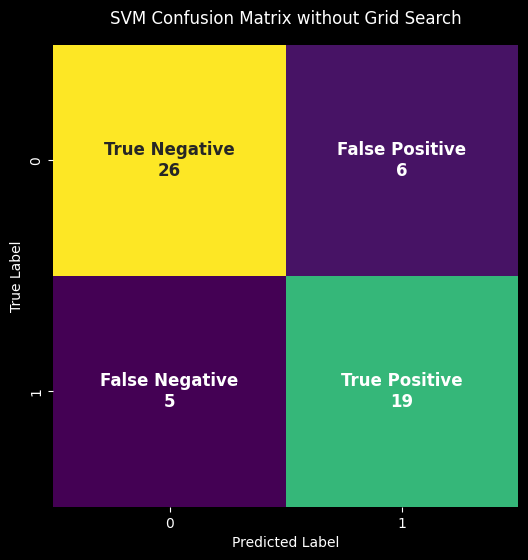

In [179]:
cm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)

group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
group_counts = [str(value) for value in cm.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2, 2)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='viridis', cbar=False, 
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_, 
            ax=ax, annot_kws={"size": 12, "weight": "bold"})

plt.title("SVM Confusion Matrix without Grid Search", pad=15)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [176]:
# we use an algorithm called grid search to find the optimal values for our hyperparameters 
# instead of just picking them randomly like i did above

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'] # added gamma to give the rbf/poly kernels more tuning options
}

svm_base = SVC(random_state=42)

svm_grid = GridSearchCV(estimator=svm_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# cv = 5 means we are doing 5-fold cross-validation
# n_jobs=-1 means we are using all available CPU cores to speed up the search process



In [181]:
svm_grid.fit(X_train, y_train)
y_pred_grid_search_svm = svm_grid.predict(X_test)
accuracy_of_grid_search_svm = accuracy_score(y_test, y_pred_grid_search_svm)
best_svm = svm_grid.best_estimator_

print("--- SVM Model Evaluation ---")
print("Best Hyperparameters Found:", svm_grid.best_params_)
print("Best Cross-Validation Accuracy: ", f"{accuracy_of_grid_search_svm:.3f}")

--- SVM Model Evaluation ---
Best Hyperparameters Found: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross-Validation Accuracy:  0.839


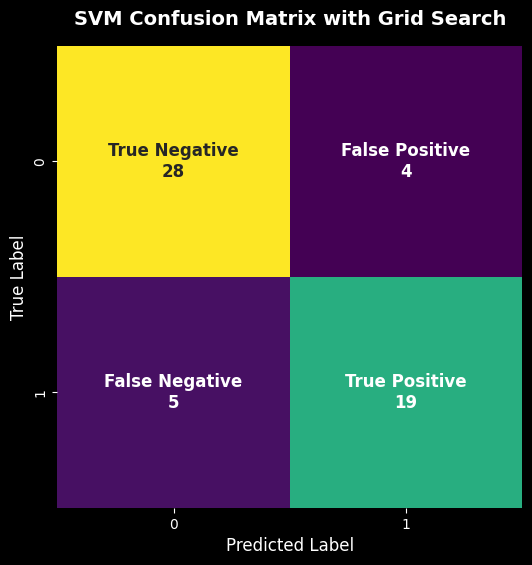

In [178]:
plt.style.use('dark_background')

cm = confusion_matrix(y_test, y_pred_grid_search_svm, labels=best_svm.classes_)

group_names = ['True Negative', 'False Positive', 'False Negative', 'True Positive']
group_counts = [str(value) for value in cm.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2, 2)

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='viridis', cbar=False, 
            xticklabels=best_svm.classes_, yticklabels=best_svm.classes_, 
            ax=ax, annot_kws={"size": 12, "weight": "bold"})

plt.title("SVM Confusion Matrix with Grid Search", pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()